In [ ]:
from querysource.queries import QS

qs = QS(slug='financial_ed_all_data_revenue')

revenue, errors = await qs.query(output_format='pandas')

In [12]:
print(revenue)

    order_month  ytd_flag    period new_project_name                      id  \
0    2022-01-01         0  Jan 2022           Altice       Altice-2022-01-01   
1    2022-02-01         0  Feb 2022           Altice       Altice-2022-02-01   
2    2022-03-01         0  Mar 2022           Altice       Altice-2022-03-01   
3    2022-04-01         0  Apr 2022           Altice       Altice-2022-04-01   
4    2022-05-01         0  May 2022           Altice       Altice-2022-05-01   
..          ...       ...       ...              ...                     ...   
720  2023-12-01         0  Dec 2023      Walmart WSP  Walmart WSP-2023-12-01   
721  2024-01-01         1  Jan 2024      Walmart WSP  Walmart WSP-2024-01-01   
722  2024-02-01         1  Feb 2024      Walmart WSP  Walmart WSP-2024-02-01   
723  2024-03-01         1  Mar 2024      Walmart WSP  Walmart WSP-2024-03-01   
724  2024-04-01         1  Apr 2024      Walmart WSP  Walmart WSP-2024-04-01   

           Revenue       EBITDA   Net I

Making some transformations on DF Revenue Columns:

In [13]:
from querysource.handlers.transformations.map_functions import from_currency

df = from_currency(revenue, 'Revenue', symbol='$', remove_nan=True)
print(df)

    order_month  ytd_flag    period new_project_name                      id  \
0    2022-01-01         0  Jan 2022           Altice       Altice-2022-01-01   
1    2022-02-01         0  Feb 2022           Altice       Altice-2022-02-01   
2    2022-03-01         0  Mar 2022           Altice       Altice-2022-03-01   
3    2022-04-01         0  Apr 2022           Altice       Altice-2022-04-01   
4    2022-05-01         0  May 2022           Altice       Altice-2022-05-01   
..          ...       ...       ...              ...                     ...   
720  2023-12-01         0  Dec 2023      Walmart WSP  Walmart WSP-2023-12-01   
721  2024-01-01         1  Jan 2024      Walmart WSP  Walmart WSP-2024-01-01   
722  2024-02-01         1  Feb 2024      Walmart WSP  Walmart WSP-2024-02-01   
723  2024-03-01         1  Mar 2024      Walmart WSP  Walmart WSP-2024-03-01   
724  2024-04-01         1  Apr 2024      Walmart WSP  Walmart WSP-2024-04-01   

        Revenue       EBITDA   Net Inco

In [17]:
print(df)

    order_month  ytd_flag    period new_project_name                      id  \
0    2022-01-01         0  Jan 2022           Altice       Altice-2022-01-01   
1    2022-02-01         0  Feb 2022           Altice       Altice-2022-02-01   
2    2022-03-01         0  Mar 2022           Altice       Altice-2022-03-01   
3    2022-04-01         0  Apr 2022           Altice       Altice-2022-04-01   
4    2022-05-01         0  May 2022           Altice       Altice-2022-05-01   
..          ...       ...       ...              ...                     ...   
720  2023-12-01         0  Dec 2023      Walmart WSP  Walmart WSP-2023-12-01   
721  2024-01-01         1  Jan 2024      Walmart WSP  Walmart WSP-2024-01-01   
722  2024-02-01         1  Feb 2024      Walmart WSP  Walmart WSP-2024-02-01   
723  2024-03-01         1  Mar 2024      Walmart WSP  Walmart WSP-2024-03-01   
724  2024-04-01         1  Apr 2024      Walmart WSP  Walmart WSP-2024-04-01   

        Revenue     EBITDA  Net Income 

In [18]:
import pandas
#df = from_currency(df, 'EBITDA', symbol='$', remove_nan=True)
#df = from_currency(df, 'Net Income', symbol='$', remove_nan=True)
df['Period'] = pandas.to_datetime(df['order_month'], errors='coerce')

# last status:
print(df)

    order_month  ytd_flag    period new_project_name                      id  \
0    2022-01-01         0  Jan 2022           Altice       Altice-2022-01-01   
1    2022-02-01         0  Feb 2022           Altice       Altice-2022-02-01   
2    2022-03-01         0  Mar 2022           Altice       Altice-2022-03-01   
3    2022-04-01         0  Apr 2022           Altice       Altice-2022-04-01   
4    2022-05-01         0  May 2022           Altice       Altice-2022-05-01   
..          ...       ...       ...              ...                     ...   
720  2023-12-01         0  Dec 2023      Walmart WSP  Walmart WSP-2023-12-01   
721  2024-01-01         1  Jan 2024      Walmart WSP  Walmart WSP-2024-01-01   
722  2024-02-01         1  Feb 2024      Walmart WSP  Walmart WSP-2024-02-01   
723  2024-03-01         1  Mar 2024      Walmart WSP  Walmart WSP-2024-03-01   
724  2024-04-01         1  Apr 2024      Walmart WSP  Walmart WSP-2024-04-01   

        Revenue     EBITDA  Net Income 

### Importing a Facebook Forecasting Library (FB Prophet)


from prophet import Prophet

In [19]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

In [20]:
# We need 2 required columns: ds and y.

df['ds'] = pandas.to_datetime(df['Period'])
df['y'] = df['Revenue']

print(df.head())

  order_month  ytd_flag    period new_project_name                 id  \
0  2022-01-01         0  Jan 2022           Altice  Altice-2022-01-01   
1  2022-02-01         0  Feb 2022           Altice  Altice-2022-02-01   
2  2022-03-01         0  Mar 2022           Altice  Altice-2022-03-01   
3  2022-04-01         0  Apr 2022           Altice  Altice-2022-04-01   
4  2022-05-01         0  May 2022           Altice  Altice-2022-05-01   

     Revenue     EBITDA  Net Income EBITDA Budget Net Income Budget  \
0  487387.70   98981.16    98981.16   $135,099.07       $135,099.07   
1  466345.38   93214.26    93214.26    $72,240.60        $72,240.60   
2  457934.48   77453.23    77453.23    $55,596.60        $55,596.60   
3  518669.61  103560.94   103560.94    $19,481.39        $19,481.39   
4  503192.80  121121.61   121121.61    $19,481.39        $19,481.39   

  Revenue Budget     Period         ds          y  
0    $400,000.00 2022-01-01 2022-01-01  487387.70  
1    $400,000.00 2022-02-01 20

New instance of Prophet, and fit the model:

In [21]:
p = Prophet()
p.fit(df)

[INFO] 2024-05-17 17:28:59,586 prophet|961 ::                 Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
[INFO] 2024-05-17 17:28:59,586 prophet(forecaster.py:961) :: Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
[INFO] 2024-05-17 17:28:59,613 prophet|961 ::                 Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
[INFO] 2024-05-17 17:28:59,613 prophet(forecaster.py:961) :: Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
[DEBUG] 2024-05-17 17:28:59,662 cmdstanpy|118 ::                 input tempfile: /tmp/tmp4_z3h8j6/ilzgd9ww.json
[DEBUG] 2024-05-17 17:28:59,662 cmdstanpy(filesystem.py:118) :: input tempfile: /tmp/tmp4_z3h8j6/ilzgd9ww.json
[DEBUG] 2024-05-17 17:28:59,759 cmdstanpy|118 ::                 input tempfile: /tmp/tmp4_z3h8j6/9pmtni63.json
[DEBUG] 2024-05-17 17:28:59,759 cmdstanpy(filesystem.py:118) :: inp

17:28:59 - cmdstanpy - INFO - Chain [1] start processing


[INFO] 2024-05-17 17:28:59,786 cmdstanpy|2058 ::                 Chain [1] start processing
[INFO] 2024-05-17 17:28:59,786 cmdstanpy(model.py:2058) :: Chain [1] start processing


17:28:59 - cmdstanpy - INFO - Chain [1] done processing


[INFO] 2024-05-17 17:28:59,902 cmdstanpy|2115 ::                 Chain [1] done processing
[INFO] 2024-05-17 17:28:59,902 cmdstanpy(model.py:2115) :: Chain [1] done processing


In [23]:
futures = p.make_future_dataframe(periods=12, freq='M')
forecast = p.predict(futures)

print(forecast.tail())

           ds          trend    yhat_lower    yhat_upper    trend_lower  \
35 2024-11-30  325104.956061 -1.017449e+06  1.614671e+06  325103.413022   
36 2024-12-31  312704.625098 -1.110816e+06  1.706004e+06  312702.790435   
37 2025-01-31  300304.294134 -1.117260e+06  1.659826e+06  300302.089536   
38 2025-02-28  289103.995199 -1.033545e+06  1.612464e+06  289101.393442   
39 2025-03-31  276703.664235 -1.177387e+06  1.617528e+06  276700.719785   

      trend_upper  additive_terms  additive_terms_lower  additive_terms_upper  \
35  325106.435790    23217.505302          23217.505302          23217.505302   
36  312706.434783   -34633.243957         -34633.243957         -34633.243957   
37  300306.426416   -41984.183872         -41984.183872         -41984.183872   
38  289106.467888    18793.296082          18793.296082          18793.296082   
39  276706.529281   -40486.371899         -40486.371899         -40486.371899   

          yearly  yearly_lower  yearly_upper  multiplicative_t

/home/jesuslara/proyectos/parallel/querysource/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


/home/jesuslara/proyectos/parallel/querysource/.venv/lib/python3.10/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/home/jesuslara/proyectos/parallel/querysource/.venv/lib/python3.10/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/home/jesuslara/proyectos/parallel/querysource/.venv/lib/python3.10/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version thi

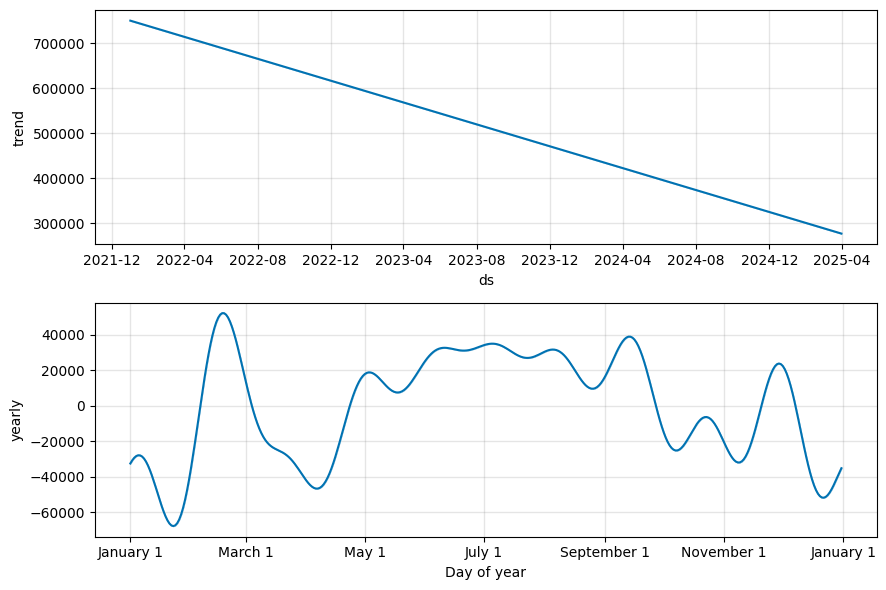

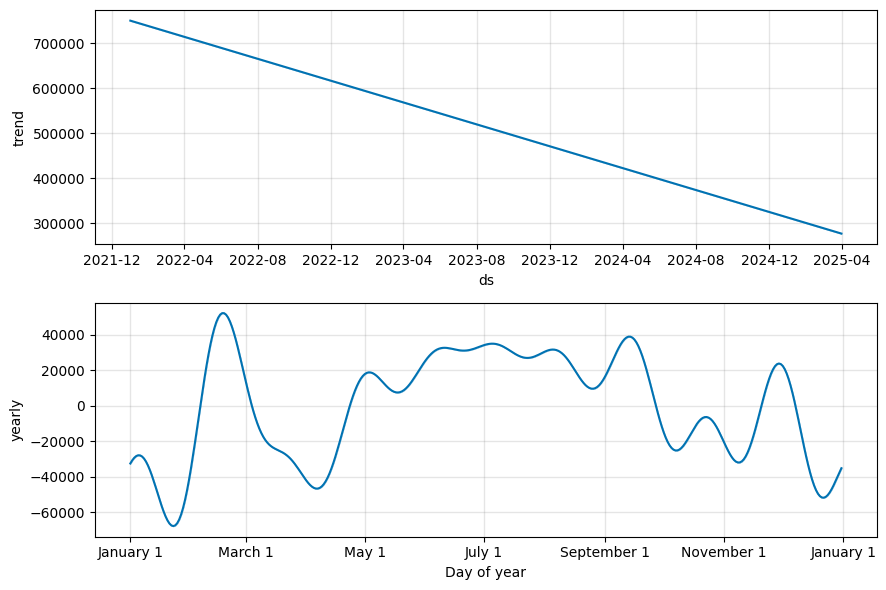

In [24]:
p.plot_components(forecast)

/home/jesuslara/proyectos/parallel/querysource/.venv/lib/python3.10/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/home/jesuslara/proyectos/parallel/querysource/.venv/lib/python3.10/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


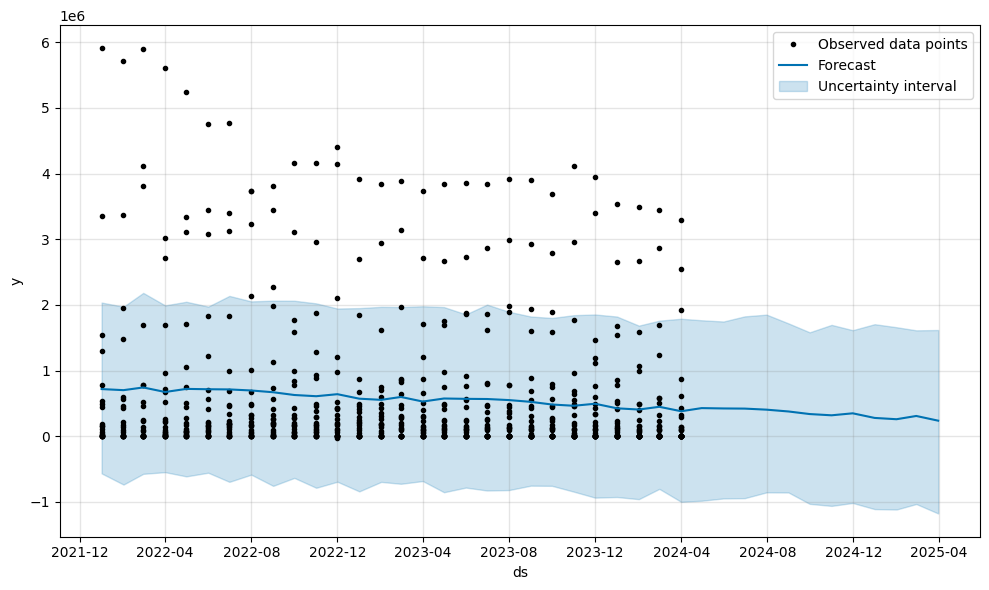

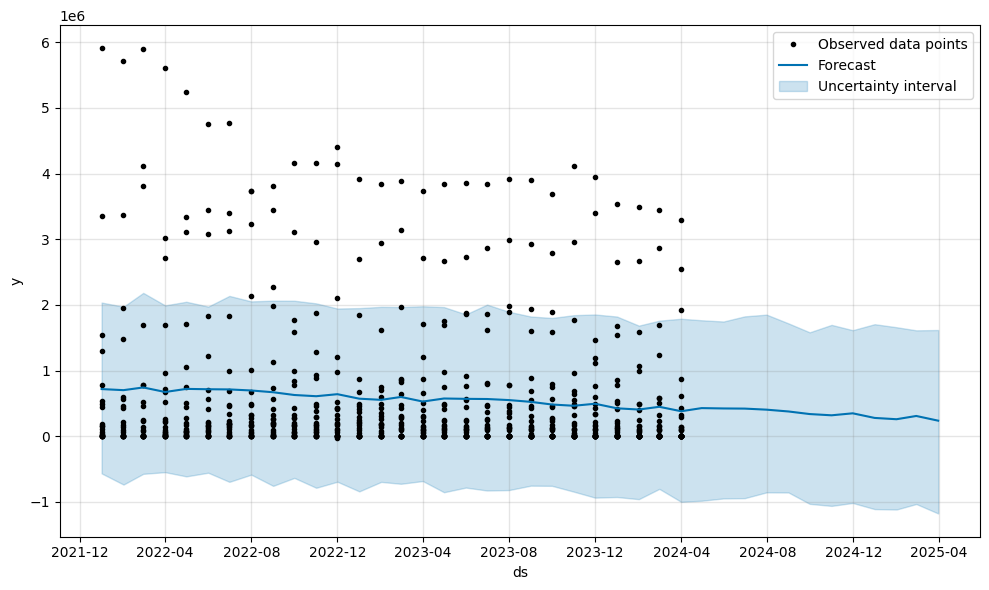

In [25]:
p.plot(forecast, plot_cap=True, include_legend=True)